### Q1 - Part I: Randomized Sales Data Generation

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# as seed should be in valid range
# so taking modulo.
ROLL_NUMBER = 8025320082
np.random.seed(ROLL_NUMBER % (2**32))

categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Generate 12 months of data for 4 categories
sales_matrix = np.random.randint(low=1000, high=5001, size=(12, 4))
df_sales = pd.DataFrame(data=sales_matrix, index=months, columns=categories)

display(df_sales)

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3437,3067,2296,4434
Feb,1743,1364,3535,3630
Mar,2694,4381,1043,1150
Apr,2319,4906,1235,1910
May,1648,2299,2790,3637
Jun,1734,1330,3959,4327
Jul,3957,2288,4447,3268
Aug,1732,1686,4250,4358
Sep,1239,2285,2167,1370
Oct,3783,2285,1305,1683


### Q1 - Part II: Data Manipulation and Analysis


In [25]:
# 1. Display first 5 rows and summary statistics
display(df_sales.head())
display(df_sales.describe())

# 2. Calculate aggregations across rows (categories) and columns (months)
total_sales_category = df_sales.sum(axis=0)
total_sales_month = df_sales.sum(axis=1)

print("\nTotal Sales per Category:\n", total_sales_category)
print("\nTotal Sales per Month:\n", total_sales_month)

# 3. Calculate average sales growth between consecutive months
avg_growth_category = df_sales.pct_change().mean() * 100
print("\nAverage Monthly Growth Rate (%) per Category:\n", avg_growth_category)

# 4. Add Total Sales and overall Growth Rate columns
df_sales['Total Sales'] = df_sales[categories].sum(axis=1)
df_sales['Growth Rate (%)'] = df_sales['Total Sales'].pct_change() * 100

# 5. Apply conditional discount based on roll number parity
if ROLL_NUMBER % 2 == 0:
    df_sales['Electronics'] = df_sales['Electronics'] * 0.90
else:
    df_sales['Clothing'] = df_sales['Clothing'] * 0.85

display(df_sales)

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3437,3067,2296,4434
Feb,1743,1364,3535,3630
Mar,2694,4381,1043,1150
Apr,2319,4906,1235,1910
May,1648,2299,2790,3637


,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,2750.416667,2658.666667,2643.750000,2852.583333
std,1167.502265,1372.982708,1295.243054,1253.493189
min,1239.000000,1086.000000,1043.000000,1150.000000
25%,1733.500000,1605.500000,1287.500000,1659.500000
50%,2506.500000,2286.500000,2543.000000,3071.500000
75%,3826.500000,3395.500000,3702.500000,3809.500000
max,4514.000000,4927.000000,4447.000000,4434.000000



Total Sales per Category:
 Electronics       33005
Clothing          31904
Home & Kitchen    31725
Sports            34231
dtype: int64

Total Sales per Month:
 Jan    13234
Feb    10272
Mar     9268
Apr    10370
May    10374
Jun    11350
Jul    13960
Aug    12026
Sep     7061
Oct     9056
Nov    14338
Dec     9556
dtype: int64

Average Monthly Growth Rate (%) per Category:
 Electronics       21.361376
Clothing          18.297192
Home & Kitchen    17.804082
Sports            11.594010
dtype: float64


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate (%)
Jan,3093.3,3067,2296,4434,13234,NaN
Feb,1568.7,1364,3535,3630,10272,-22.381744
Mar,2424.6,4381,1043,1150,9268,-9.774143
Apr,2087.1,4906,1235,1910,10370,11.890375
May,1483.2,2299,2790,3637,10374,0.038573
Jun,1560.6,1330,3959,4327,11350,9.408136
Jul,3561.3,2288,4447,3268,13960,22.995595
Aug,1558.8,1686,4250,4358,12026,-13.853868
Sep,1115.1,2285,2167,1370,7061,-41.285548
Oct,3404.7,2285,1305,1683,9056,28.253788


### Q1 - Part III: Visualizations (Matplotlib and Seaborn)

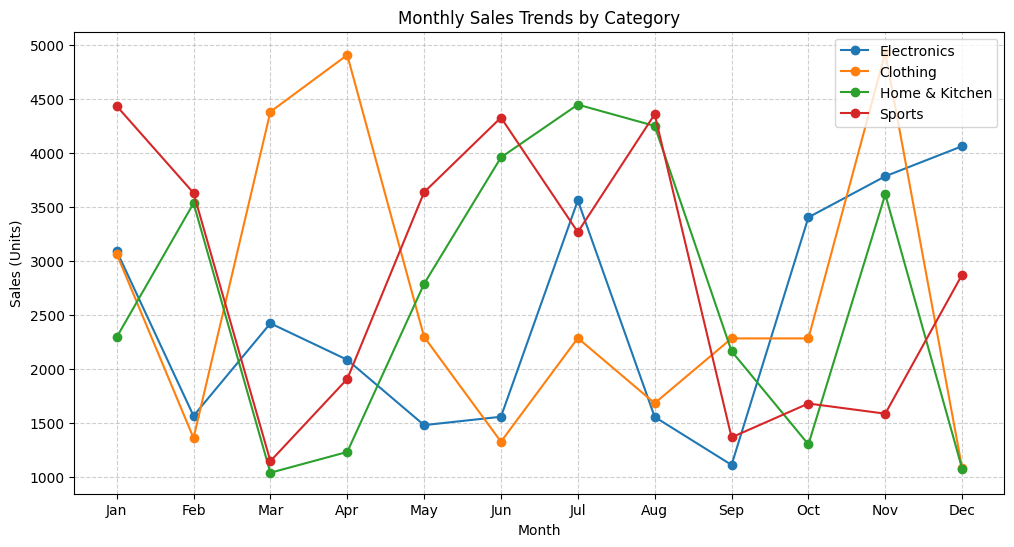

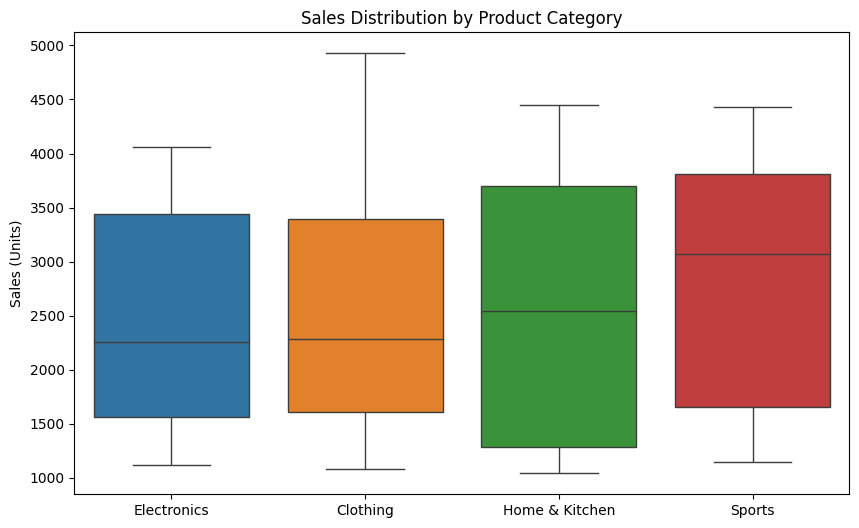

In [26]:
# 1. Line plots for monthly sales trends
plt.figure(figsize=(12, 6))
for category in categories:
    plt.plot(df_sales.index, df_sales[category], marker='o', label=category)

plt.title('Monthly Sales Trends by Category')
plt.xlabel('Month')
plt.ylabel('Sales (Units)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Box plots for sales distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sales[categories])

plt.title('Sales Distribution by Product Category')
plt.ylabel('Sales (Units)')
plt.show()

### Q2: Array Statistical Analysis


In [27]:
array_q2 = np.array([[1, 2, 3], [-4, 5, -6]])
print("Original Array:\n", array_q2)

# i. Element-wise absolute value
print("\nAbsolute Value:\n", np.abs(array_q2))

# ii. Percentiles (Flattened, Columns, Rows)
print("\nPercentiles (25th, 50th, 75th):")
print("Flattened:", np.percentile(array_q2, [25, 50, 75]))
print("Columns:\n", np.percentile(array_q2, [25, 50, 75], axis=0))
print("Rows:\n", np.percentile(array_q2, [25, 50, 75], axis=1))

# iii. Statistical Metrics
print("\nStatistical Metrics (Flat, Col, Row):")
print("Mean:", np.mean(array_q2), "|", np.mean(array_q2, axis=0), "|", np.mean(array_q2, axis=1))
print("Median:", np.median(array_q2), "|", np.median(array_q2, axis=0), "|", np.median(array_q2, axis=1))
print("Std Dev:", np.std(array_q2), "|", np.std(array_q2, axis=0), "|", np.std(array_q2, axis=1))

Original Array:
 [[ 1  2  3]
 [-4  5 -6]]

Absolute Value:
 [[1 2 3]
 [4 5 6]]

Percentiles (25th, 50th, 75th):
Flattened: [-2.75  1.5   2.75]
Columns:
 [[-2.75  2.75 -3.75]
 [-1.5   3.5  -1.5 ]
 [-0.25  4.25  0.75]]
Rows:
 [[ 1.5 -5. ]
 [ 2.  -4. ]
 [ 2.5  0.5]]

Statistical Metrics (Flat, Col, Row):
Mean: 0.16666666666666666 | [-1.5  3.5 -1.5] | [ 2.         -1.66666667]
Median: 1.5 | [-1.5  3.5 -1.5] | [ 2. -4.]
Std Dev: 3.890872509976251 | [2.5 1.5 4.5] | [0.81649658 4.78423336]


### Q3: Array Rounding Operations


In [28]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
print("Original array:", a)

# Apply specific NumPy rounding functions
print("Floor values:", np.floor(a))
print("Ceiling values:", np.ceil(a))
print("Truncated values:", np.trunc(a))
print("Rounded values:", np.round(a))

Original array: [-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]
Floor values: [-2. -2. -1.  0.  1.  1.  3.]
Ceiling values: [-1. -1. -0.  1.  2.  2.  3.]
Truncated values: [-1. -1. -0.  0.  1.  1.  3.]
Rounded values: [-2. -2. -0.  0.  2.  2.  3.]


### Q4 & Q5: Swapping Elements in Lists and Sets

In [29]:
# Q4: Swap elements in a list using a temporary variable
my_list = [10, 20, 30, 40, 50]
idx1, idx2 = 1, 3

temp = my_list[idx1]
my_list[idx1] = my_list[idx2]
my_list[idx2] = temp

print("Q4 - List after swap:", my_list)

# Q5: Swap elements in a set by converting to a list
my_set = {'apple', 'banana', 'cherry', 'date'}

# Cast to list to enable indexing
temp_list = list(my_set)
temp_list[0], temp_list[2] = temp_list[2], temp_list[0]

swapped_set = set(temp_list)
print("Q5 - Set after swap:", swapped_set)

Q4 - List after swap: [10, 40, 30, 20, 50]
Q5 - Set after swap: {'apple', 'date', 'cherry', 'banana'}
